# Proyek Analisis Sentimen pada Review Sebuah Restoran

Tujuan dari proyek ini adalah untuk membuat sebuah model yang dapat memprediksi apakah review sebuah restoran merupakan review positif atau negatif. Proyek ini menggunakan [dataset yield](https://www.kaggle.com/marklvl/sentiment-labelled-sentences-data-set), dataset tersebut yang berisi kumpulan review terhap sebuah restoran.

In [3]:
%pip install pandas tensorflow scikit-learn matplotlib numpy nltk

  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl (11.3 MB)
  Using cached tensorflow-2.21.0-cp310-cp310-win_amd64.whl (350.6 MB)
  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
  Using cached matplotlib-3.10.8-cp310-cp310-win_amd64.whl (8.1 MB)
  Using cached nltk-3.9.4-py3-none-any.whl (1.6 MB)
  Using cached ml_dtypes-0.5.4-cp310-cp310-win_amd64.whl (210 kB)
  Using cached grpcio-1.80.0-cp310-cp310-win_amd64.whl (4.9 MB)
  Using cached keras-3.12.1-py3-none-any.whl (1.5 MB)
  Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
  Using cached requests-2.33.1-py3-none-any.whl (64 kB)
  Using cached h5py-3.14.0-cp310-cp310-win_amd64.whl (2.9 MB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl (41.3 MB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
  Using cached click-8.3.2-py3-none-any.whl (108 kB)
  Using cached optree-0.19.0-cp310-cp310-win_amd64.whl (321 kB)
  Using 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense#, LSTM, Bidirectional
import matplotlib.pyplot as plt
import numpy as np
import nltk
from nltk.corpus import stopwords
import json

## Mempersiapkan Dataset

In [5]:
df = pd.read_csv('yelp_labelled.txt', names=['sentence', 'label'], sep='\t')
df.head()

,sentence,label
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sentence  1000 non-null   object
 1   label     1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


Berdasarkan keterangan di atas diketahui bahwa dataset yang digunakan terdiri dari 1000 data dan tidak terdapat *missing value*.

## Preprocessing Data

### Mengubah seluruh text kedalam bentuk lowercase

In [7]:
df['sentence'] = df['sentence'].str.lower()

df.head()

,sentence,label
0,wow... loved this place.,1
1,crust is not good.,0
2,not tasty and the texture was just nasty.,0
3,stopped by during the late may bank holiday of...,1
4,the selection on the menu was great and so wer...,1


### Menghilangkan [stopwords](https://en.wikipedia.org/wiki/Stop_word)

In [10]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [11]:
stop_word = set(stopwords.words('english'))

df['sentence'] = df['sentence'].apply(lambda x:' '.join([word for word in x.split() if word not in (stop_word)]))

df.head()

,sentence,label
0,wow... loved place.,1
1,crust good.,0
2,tasty texture nasty.,0
3,stopped late may bank holiday rick steve recom...,1
4,selection menu great prices.,1


### Melakukan split dataset

In [12]:
sentence = df['sentence'].values
label = df['label'].values

In [13]:
sentence_train, sentence_test, label_train, label_test = train_test_split(sentence, label, test_size=0.2, shuffle=False)

print('Training dataset:\n', sentence_train.shape, label_train.shape)
print('\nTest dataset:\n', sentence_test.shape, label_test.shape)

Training dataset:
 (800,) (800,)

Test dataset:
 (200,) (200,)


### Membuat tokenisasi

In [14]:
filt = '!"#$%&()*+.,-/:;=?@[\]^_`{|}~ ' # Untuk menghilangkan symbols

tokenizer = Tokenizer(num_words=2000, oov_token="<OOV>", filters=filt)

tokenizer.fit_on_texts(sentence_train)

In [15]:
word_index = tokenizer.word_index
print(len(word_index))

1720


In [16]:
# Menyimpan word_index kedalam sebuah file json

with open('word_index.json', 'w') as fp:
    json.dump(word_index, fp)

### Membuat sequences dan melakukan padding

In [17]:
train_sekuens = tokenizer.texts_to_sequences(sentence_train)
test_sekuens = tokenizer.texts_to_sequences(sentence_test)


train_padded = pad_sequences(train_sekuens, 
                             maxlen=20,
                             padding='post',
                             truncating='post')
test_padded = pad_sequences(test_sekuens,
                            maxlen=20,
                            padding='post',
                            truncating='post')

In [18]:
train_padded.shape

(800, 20)

In [19]:
test_padded.shape

(200, 20)

## Membuat Model

In [21]:
model = tf.keras.Sequential([
    Embedding(2000, 20, input_length=20),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

## Melatih Model

In [23]:
num_epochs = 30
history = model.fit(train_padded, label_train, 
                    epochs=num_epochs, 
                    validation_data=(test_padded, label_test),
                    verbose=1)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5650 - loss: 0.6857 - val_accuracy: 0.2400 - val_loss: 0.7755
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5650 - loss: 0.6804 - val_accuracy: 0.2400 - val_loss: 0.7773
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5700 - loss: 0.6740 - val_accuracy: 0.2450 - val_loss: 0.7445
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5913 - loss: 0.6570 - val_accuracy: 0.2600 - val_loss: 0.7727
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6600 - loss: 0.6170 - val_accuracy: 0.3350 - val_loss: 0.7323
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8225 - loss: 0.5221 - val_accuracy: 0.5700 - val_loss: 0.6518
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8938 - loss: 0.3828 - val_accuracy: 0.5250 - val_loss: 0.7030
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9287 - loss: 0.2584 - val_accuracy: 0.8250 - val_l

## Evaluasi Model

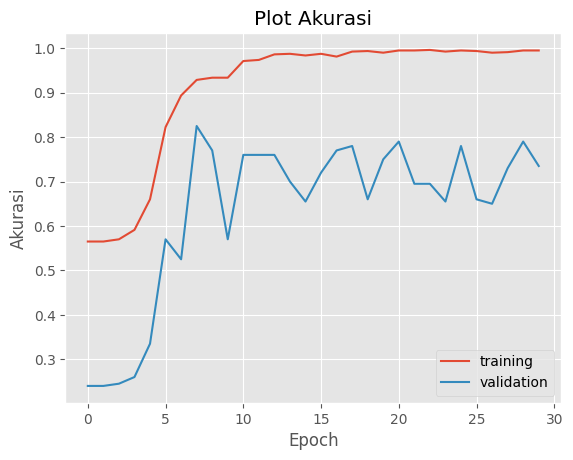

In [24]:
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, num_epochs), history.history["accuracy"], label="training")
plt.plot(np.arange(0, num_epochs), history.history["val_accuracy"], label="validation")
plt.title("Plot Akurasi")
plt.xlabel("Epoch")
plt.ylabel("Akurasi")
plt.legend()
plt.savefig('images/plot_acc.png')
plt.show()

Berdasarkan plot tersebut dapat dilihat bahwa model yang digunakan masih sangat overfit 

## Save Model

In [25]:
model.save("model.h5")

## Convert Model

In [26]:
# Install tensorflowjs

%pip install tensorflowjs


     ---------------------------------------- 0.0/89.1 kB ? eta -:--:--
     ---------------------------------------- 89.1/89.1 kB 2.5 MB/s eta 0:00:00
     ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
     -- ------------------------------------- 0.1/2.7 MB 2.8 MB/s eta 0:00:01
     ----- ---------------------------------- 0.4/2.7 MB 4.0 MB/s eta 0:00:01
     -------- ------------------------------- 0.6/2.7 MB 4.6 MB/s eta 0:00:01
     -------- ------------------------------- 0.6/2.7 MB 4.6 MB/s eta 0:00:01
     ---------- ----------------------------- 0.7/2.7 MB 3.2 MB/s eta 0:00:01
     ----------- ---------------------------- 0.8/2.7 MB 3.2 MB/s eta 0:00:01
     ------------- -------------------------- 0.9/2.7 MB 2.8 MB/s eta 0:00:01
     ------------- -------------------------- 0.9/2.7 MB 2.7 MB/s eta 0:00:01
     ------------- -------------------------- 0.9/2.7 MB 2.7 MB/s eta 0:00:01
     --------------- ------------------------ 1.0/2.7 MB 2.3 MB/s eta 0:00

ERROR: Could not install packages due to an OSError: [Errno 28] No space left on device


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     -------------------------- ----------- 211.0/300.9 MB 1.3 MB/s eta 0:01:11
     -------------------------- ----------- 211.0/300.9 MB 1.3 MB/s eta 0:01:10
     -------------------------- ----------- 211.1/300.9 MB 1.3 MB/s eta 0:01:10
     -------------------------- ----------- 211.2/300.9 MB 1.3 MB/s eta 0:01:10
     -------------------------- ----------- 211.2/300.9 MB 1.3 MB/s eta 0:01:10
     -------------------------- ----------- 211.2/300.9 MB 1.3 MB/s eta 0:01:11
     -------------------------- ----------- 211.2/300.9 MB 1.3 MB/s eta 0:01:11
     -------------------------- ----------- 211.3/300.9 MB 1.3 MB/s eta 0:01:11
     -------------------------- ----------- 211.3/300.9 MB 1.3 MB/s eta 0:01:11
     -------------------------- ----------- 211.3/300.9 MB 1.3 MB/s eta 0:01:11
     -------------------------- ----------- 211.4/300.9 MB 1.3 MB/s eta 0:01:11
     -------------------------- ----------- 211.4/300.9 MB 1.3 MB/s eta 0:01:11
     -------------------------- --------

In [27]:
# mengubah model.h5 kedalam bentuk json
!tensorflowjs_converter --input_format=keras model.h5 tfjs_model

'tensorflowjs_converter' is not recognized as an internal or external command,
operable program or batch file.
